In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("Step 1 complete")

Step 1 complete


In [2]:
df = pd.read_csv('creditcard.csv')

print("Dataset loaded")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded
Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Normal transactions: 284315
Fraud transactions: 492


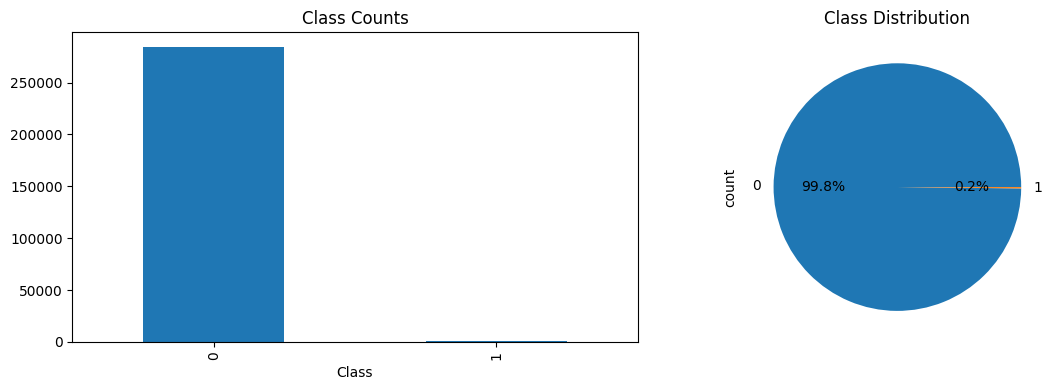


Chart saved


In [3]:
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nNormal transactions:", df['Class'].value_counts()[0])
print("Fraud transactions:", df['Class'].value_counts()[1])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Class'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Class Counts')
df['Class'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Class Distribution')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

print("\nChart saved")

Amount Analysis:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


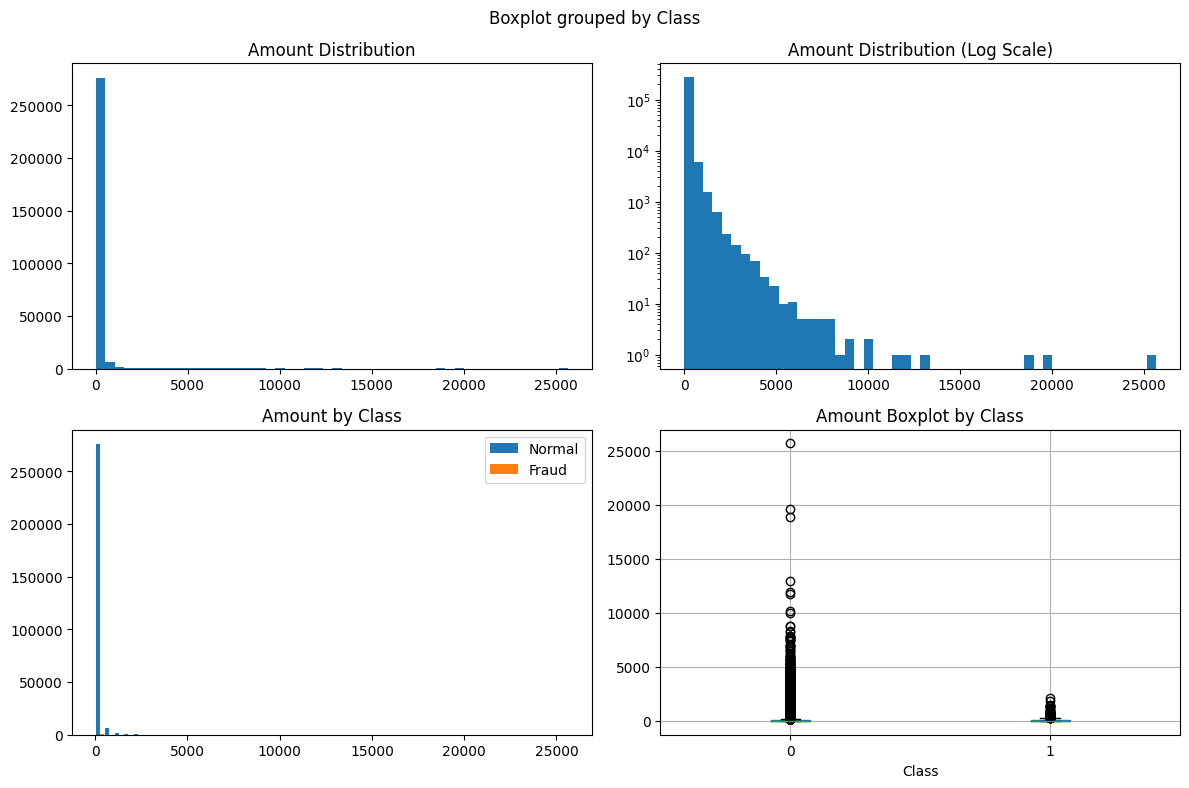

Charts saved


In [4]:
print("Amount Analysis:")
print(df['Amount'].describe())

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].hist(df['Amount'], bins=50)
ax[0, 0].set_title('Amount Distribution')

ax[0, 1].hist(df['Amount'], bins=50)
ax[0, 1].set_yscale('log')
ax[0, 1].set_title('Amount Distribution (Log Scale)')

fraud = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']
ax[1, 0].hist([normal, fraud], bins=50, label=['Normal', 'Fraud'])
ax[1, 0].set_title('Amount by Class')
ax[1, 0].legend()

df.boxplot(column='Amount', by='Class', ax=ax[1, 1])
ax[1, 1].set_title('Amount Boxplot by Class')

plt.tight_layout()
plt.savefig('amount_analysis.png')
plt.show()

print("Charts saved")

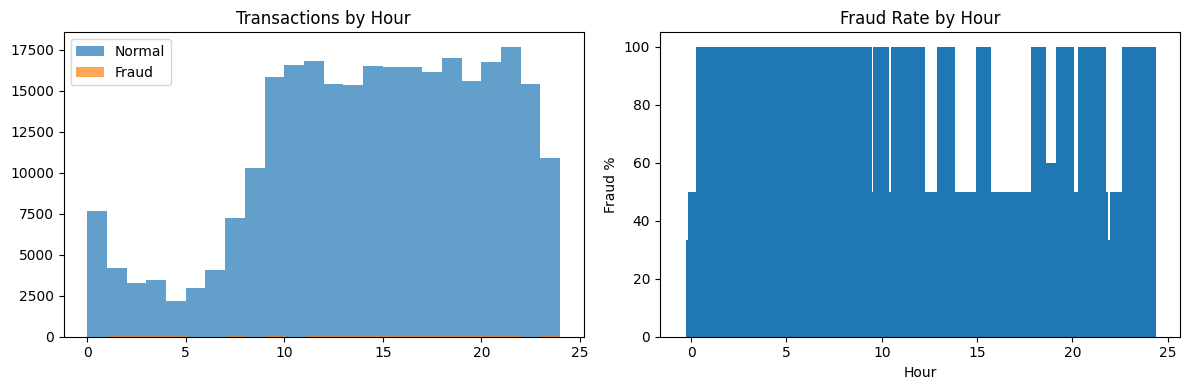

Time analysis complete


In [5]:
df['Hour'] = (df['Time'] / 3600) % 24

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df[df['Class']==0]['Hour'], bins=24, alpha=0.7, label='Normal')
ax[0].hist(df[df['Class']==1]['Hour'], bins=24, alpha=0.7, label='Fraud')
ax[0].set_title('Transactions by Hour')
ax[0].legend()

hour_fraud = df.groupby('Hour')['Class'].mean() * 100
ax[1].bar(hour_fraud.index, hour_fraud.values)
ax[1].set_title('Fraud Rate by Hour')
ax[1].set_xlabel('Hour')
ax[1].set_ylabel('Fraud %')

plt.tight_layout()
plt.savefig('time_analysis.png')
plt.show()

print("Time analysis complete")

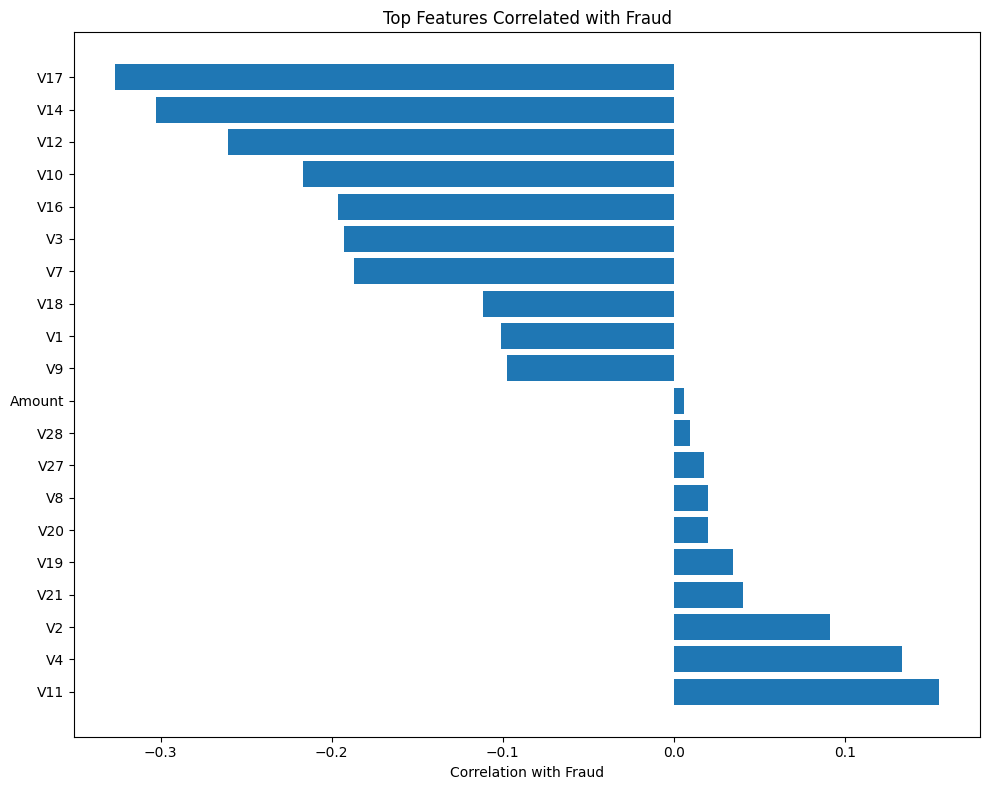

Correlation analysis complete


In [6]:
corr_matrix = df.corr()
class_corr = corr_matrix['Class'].drop('Class').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
top_features = pd.concat([class_corr.head(10), class_corr.tail(10)])
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation with Fraud')
plt.title('Top Features Correlated with Fraud')
plt.tight_layout()
plt.savefig('correlation_analysis.png')
plt.show()

print("Correlation analysis complete")

In [7]:
X = df.drop(['Class', 'Hour'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split complete")
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Data split complete
Train size: (199364, 30)
Test size: (85443, 30)


In [8]:
print("Training Logistic Regression...")

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Training Logistic Regression...

Logistic Regression Results:
Accuracy: 0.9991456292499094
Precision: 0.8504672897196262
Recall: 0.6148648648648649
F1 Score: 0.7137254901960784
ROC AUC: 0.9567188913516366

Confusion Matrix:
[[85279    16]
 [   57    91]]


In [9]:
print("Training Random Forest...")

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
y_pred_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Training Random Forest...

Random Forest Results:
Accuracy: 0.9995201479348805
Precision: 0.9572649572649573
Recall: 0.7567567567567568
F1 Score: 0.8452830188679246
ROC AUC: 0.9307455207126935

Confusion Matrix:
[[85290     5]
 [   36   112]]


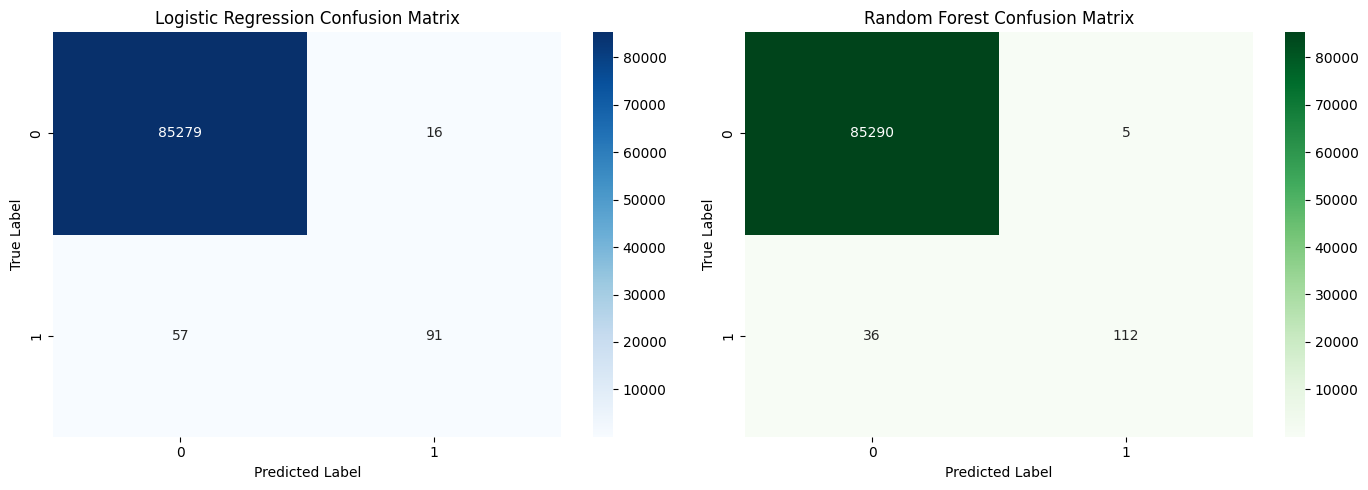

Confusion matrices saved


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_ylabel('True Label')
ax[0].set_xlabel('Predicted Label')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
ax[1].set_ylabel('True Label')
ax[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

print("Confusion matrices saved")

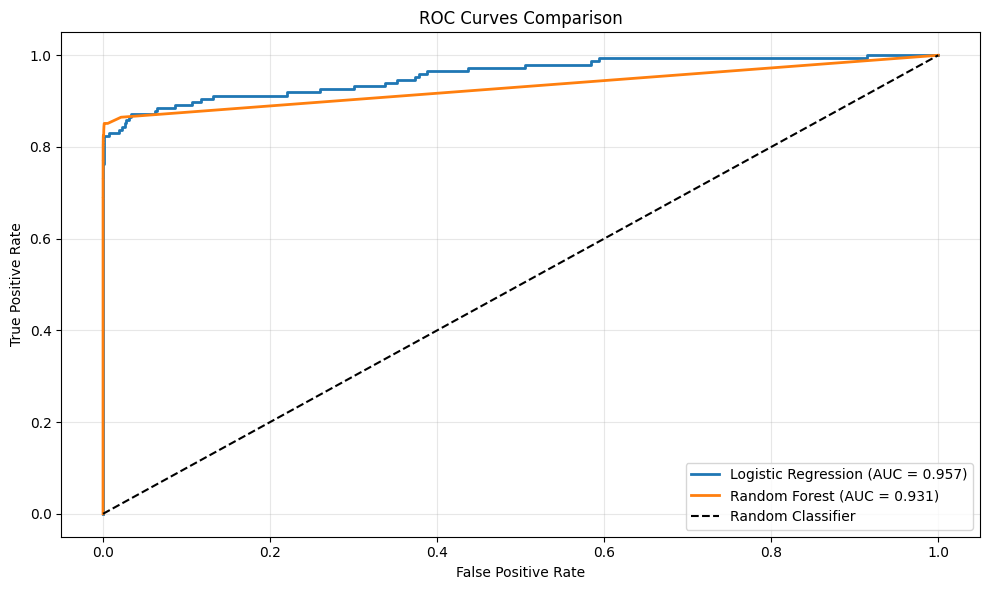

ROC curves saved


In [11]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(10, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_log):.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

print("ROC curves saved")

Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.999146   0.850467  0.614865  0.713725  0.956719
1        Random Forest  0.999520   0.957265  0.756757  0.845283  0.930746


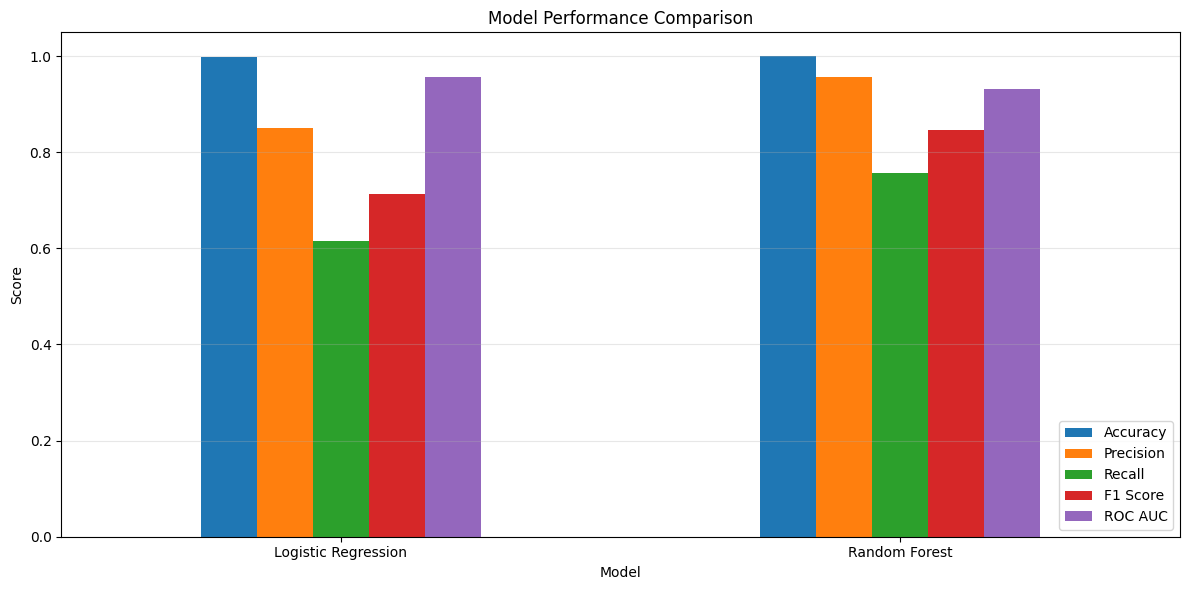

All analysis complete


In [12]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_rf)],
    'ROC AUC': [roc_auc_score(y_test, y_pred_proba_log), roc_auc_score(y_test, y_pred_proba_rf)]
})

print("Model Comparison:")
print(results_df)

results_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

print("All analysis complete")